# ☀️ Solar Energy Output Prediction: ML for Renewable Energy Forecasting

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting solar radiation/power output from weather data to support grid integration and energy policy  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting solar energy output from meteorological features (temperature, humidity, pressure, wind, cloud cover). The model supports **grid dispatch planning**, **energy market forecasting**, and **renewable energy investment decisions**.

### Government Policy Context
- **ARENA (Australian Renewable Energy Agency)** — Solar forecasting R&D, large-scale solar investment
- **CER (Clean Energy Regulator)** — Renewable Energy Target, Small-scale Renewable Energy Scheme (SRES)
- **AEMO (Australian Energy Market Operator)** — 5-minute dispatch, solar curtailment, Integrated System Plan
- **DCCEEW** — Climate Change Act 2022, 82% renewables by 2030 target
- **CEFC (Clean Energy Finance Corporation)** — Solar farm project financing, risk assessment

### Operational Decision Framework
| Forecast | Action | Stakeholder |
|-----------|--------|-------------|
| High solar output expected | Reduce gas dispatch, prepare storage charge | AEMO dispatch |
| Low output (cloud/weather) | Ramp gas/hydro reserves, manage spot price | Market operator |
| Sustained low period | Activate demand response, import from interconnector | Network operator |
| Forecast uncertainty high | Widen reserve margins, conservative bidding | Generators + retailers |

---

**Note:** This is a **regression** notebook — predicting continuous solar output. Metrics use RMSE, MAE, R².


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY — REGRESSION MODE")
print("=" * 60)


ENVIRONMENT READY — REGRESSION MODE


In [2]:
data_path = None
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path
if data_path is None:
    raise FileNotFoundError("No CSV found")
with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/dronio/SolarEnergy/SolarPrediction.csv

Loaded: 32,686 rows x 11 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    if df[col].dtype in ['int64', 'float64']:
        print(f"  {i:2d}. {col:30s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d} | range=[{df[col].min():.1f}, {df[col].max():.1f}]")
    else:
        sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
        print(f"  {i:2d}. {col:30s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. UNIXTime                       | int64      | unique= 32686 | nulls=  0 | range=[1472724008.0, 1483264501.0]
   1. Data                           | object     | unique=   118 | nulls=  0 | eg: 9/29/2016 12:00:00 AM
   2. Time                           | object     | unique=  8299 | nulls=  0 | eg: 23:55:26
   3. Radiation                      | float64    | unique= 14434 | nulls=  0 | range=[1.1, 1601.3]
   4. Temperature                    | int64      | unique=    38 | nulls=  0 | range=[34.0, 71.0]
   5. Pressure                       | float64    | unique=    38 | nulls=  0 | range=[30.2, 30.6]
   6. Humidity                       | int64      | unique=    94 | nulls=  0 | range=[8.0, 103.0]
   7. WindDirection(Degrees)         | float64    | unique= 17951 | nulls=  0 | range=[0.1, 359.9]
   8. Speed                          | float64    | unique=    37 | nulls=  0 | range=[0.0, 40.5]
   9. TimeSunRise                    | object     | unique=    51 | nulls=  0

,UNIXTime,Data,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet
0,1475229326,9/29/2016 12:00:00 AM,23:55:26,1.21,48,30.46,59,177.39,5.62,06:13:00,18:13:00
1,1475229023,9/29/2016 12:00:00 AM,23:50:23,1.21,48,30.46,58,176.78,3.37,06:13:00,18:13:00
2,1475228726,9/29/2016 12:00:00 AM,23:45:26,1.23,48,30.46,57,158.75,3.37,06:13:00,18:13:00
3,1475228421,9/29/2016 12:00:00 AM,23:40:21,1.21,48,30.46,60,137.71,3.37,06:13:00,18:13:00
4,1475228124,9/29/2016 12:00:00 AM,23:35:24,1.17,48,30.46,62,104.95,5.62,06:13:00,18:13:00


## 2. Target Variable Identification & Analysis

In [4]:
target_candidates = ['Radiation', 'radiation', 'Solar', 'solar', 'Power', 'power',
                     'output', 'Output', 'GHI', 'irradiance', 'energy', 'Energy',
                     'Target', 'target', 'DC_POWER', 'AC_POWER']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    for col in df.columns:
        if any(kw in col.lower() for kw in ['radiation', 'solar', 'power', 'irradiance', 'energy', 'output']):
            if df[col].dtype in ['int64', 'float64']:
                target_col = col
                print(f"Auto-detected: '{target_col}'")
                break

if target_col is None:
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        target_col = num_cols[-1]
        print(f"Fallback — last numeric: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nTarget: '{target_col}'")
print(f"\nStatistics:")
print(df[target_col].describe())


Found target: 'Radiation'

Target: 'Radiation'

Statistics:
count    32686.000000
mean       207.124697
std        315.916387
min          1.110000
25%          1.230000
50%          2.660000
75%        354.235000
max       1601.260000
Name: Radiation, dtype: float64


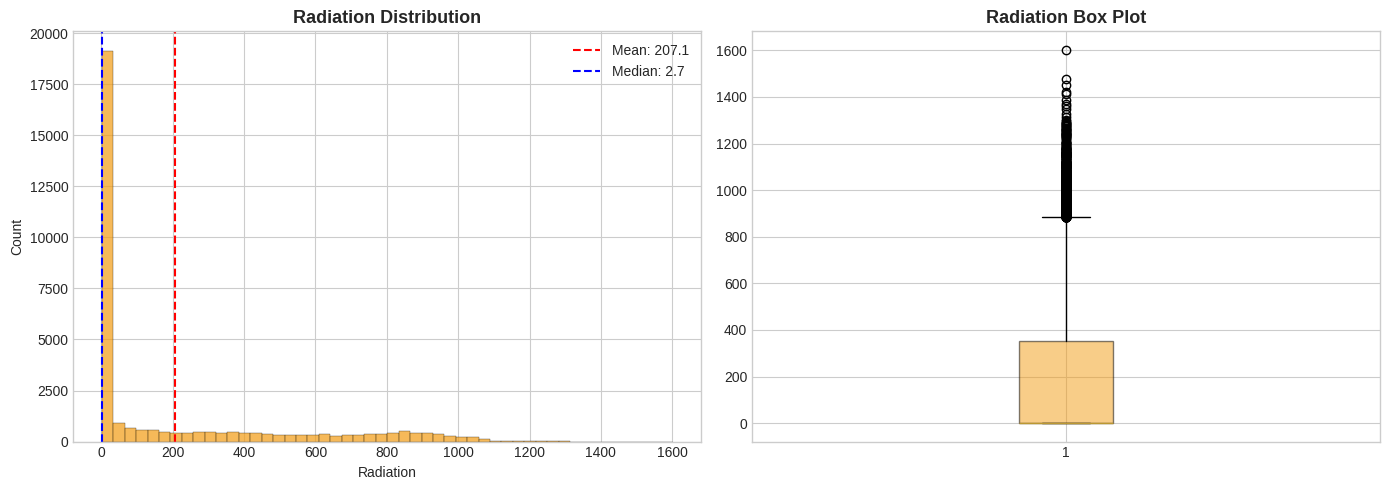

Skewness: 1.370

Australian context: Australia has the highest solar radiation per capita globally.
Rooftop solar now provides ~18% of total electricity (CER, 2023). Grid integration is critical.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[target_col].dropna(), bins=50, color='#f39c12', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[0].set_title(f'{target_col} Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel(target_col); axes[0].set_ylabel('Count')
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f'Mean: {df[target_col].mean():.1f}')
axes[0].axvline(df[target_col].median(), color='blue', linestyle='--', label=f'Median: {df[target_col].median():.1f}')
axes[0].legend()
axes[1].boxplot(df[target_col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#f39c12', alpha=0.5))
axes[1].set_title(f'{target_col} Box Plot', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
skewness = df[target_col].skew()
print(f"Skewness: {skewness:.3f}")
print("\nAustralian context: Australia has the highest solar radiation per capita globally.")
print("Rooftop solar now provides ~18% of total electricity (CER, 2023). Grid integration is critical.")


## 3. Exploratory Data Analysis

Key questions for energy policy:
- Which weather variables most strongly predict solar output?
- How do cloud cover and humidity reduce generation?
- Are there temperature effects (panel efficiency drops at extreme heat)?
- What's the diurnal pattern — can we capture time-of-day effects?


Numeric features (6): ['UNIXTime', 'Temperature', 'Pressure', 'Humidity', 'WindDirection(Degrees)', 'Speed']


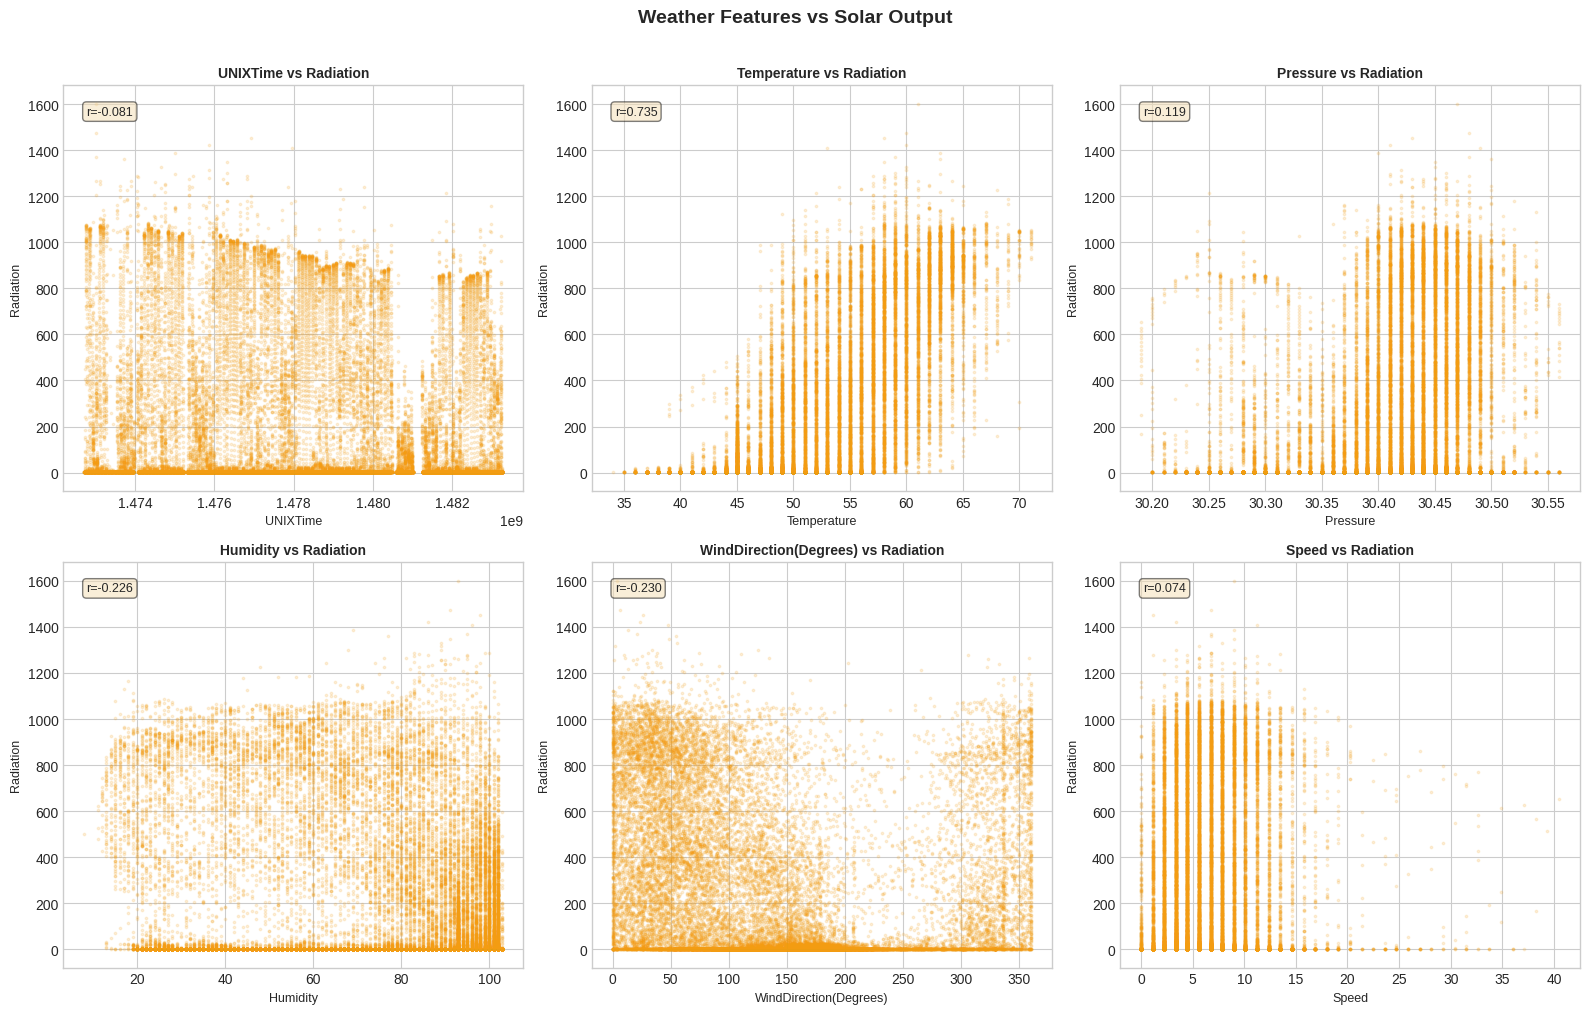

In [6]:
# Drop datetime/text columns for correlation, keep for feature engineering
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index', 'unnamed: 0']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

if len(numeric_cols) > 0:
    plot_cols = numeric_cols[:6]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        axes[i].scatter(df[col], df[target_col], alpha=0.15, s=3, color='#f39c12')
        axes[i].set_xlabel(col, fontsize=9); axes[i].set_ylabel(target_col, fontsize=9)
        axes[i].set_title(f'{col} vs {target_col}', fontsize=10, fontweight='bold')
        corr_val = df[[col, target_col]].corr().iloc[0, 1]
        axes[i].text(0.05, 0.95, f'r={corr_val:.3f}', transform=axes[i].transAxes, fontsize=9,
                     va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Weather Features vs Solar Output', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight'); plt.show()


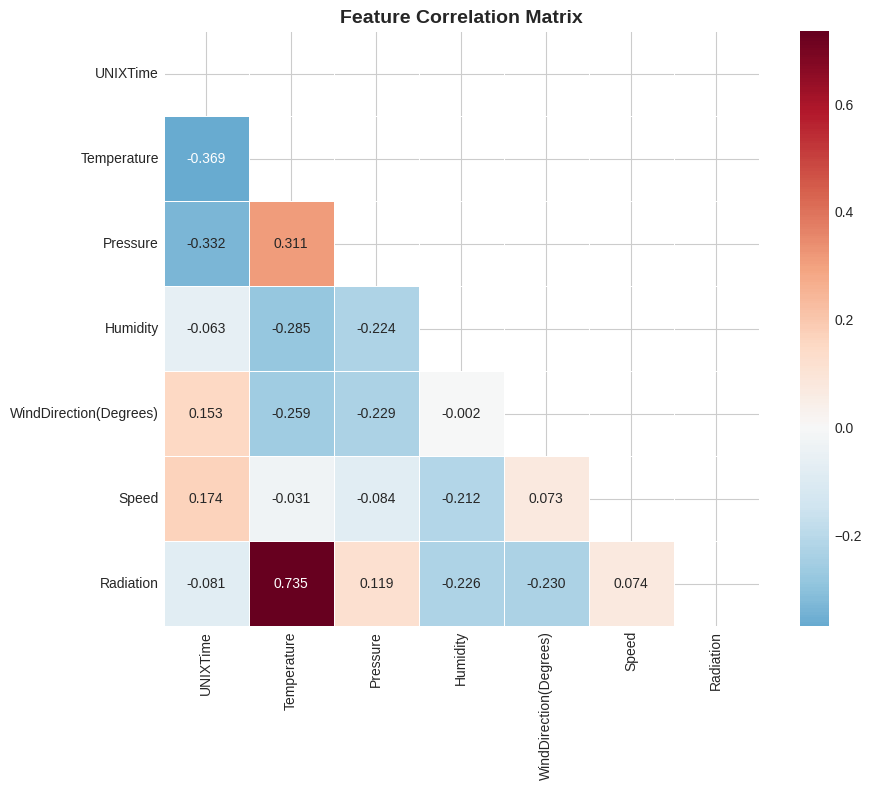

Correlations with solar output:
  Temperature                    +0.7350
  WindDirection(Degrees)         -0.2303
  Humidity                       -0.2262
  Pressure                       +0.1190
  UNIXTime                       -0.0813
  Speed                          +0.0736


In [7]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Correlations with solar output:")
    for feat, val in target_corr.items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:30s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

Solar energy models benefit from:
- **Time features** — hour of day, month (solar angle proxy)
- **Temperature-humidity interaction** — affects panel efficiency and atmospheric clarity
- **Cloud impact score** — cloud ceiling × visibility combined indicator
- **Wind chill / heat stress** — extreme temperature effects on panel output


In [8]:
df_model = df.copy()

# Try to extract time features from datetime columns
datetime_cols = [c for c in df_model.columns if df_model[c].dtype == 'object' and
                 any(kw in c.lower() for kw in ['time', 'date', 'timestamp', 'utc'])]
for dtc in datetime_cols:
    try:
        dt_parsed = pd.to_datetime(df_model[dtc], errors='coerce')
        if dt_parsed.notna().sum() > len(df_model) * 0.5:
            df_model['hour'] = dt_parsed.dt.hour
            df_model['month'] = dt_parsed.dt.month
            df_model['day_of_year'] = dt_parsed.dt.dayofyear
            print(f"Extracted time features from '{dtc}': hour, month, day_of_year")
            break
    except:
        pass

# Drop non-numeric columns
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        # Try to encode if low cardinality, otherwise drop
        if df_model[col].nunique() <= 20:
            le = LabelEncoder()
            df_model[col] = df_model[col].fillna('__MISSING__')
            df_model[col] = le.fit_transform(df_model[col].astype(str))
            print(f"  Encoded '{col}': {len(le.classes_)} classes")
        else:
            print(f"  Dropping '{col}' (high cardinality text)")
            df_model.drop(columns=[col], inplace=True)

drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"Imputing {null_counts.sum()} missing values...")
    X = X.fillna(X.median())
print(f"\nFeature matrix: {X.shape}")


Extracted time features from 'Time': hour, month, day_of_year
  Dropping 'Data' (high cardinality text)
  Dropping 'Time' (high cardinality text)
  Dropping 'TimeSunRise' (high cardinality text)
  Dropping 'TimeSunSet' (high cardinality text)

Feature matrix: (32686, 9)


In [9]:
feature_names = X.columns.tolist()
composites_added = []

# Temperature-humidity interaction (atmospheric clarity)
temp_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['temp', 'temperature'])]
humid_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['humid', 'humidity'])]
if temp_cols and humid_cols:
    X['temp_humidity_idx'] = X[temp_cols[0]] * (100 - X[humid_cols[0]]) / 100
    composites_added.append('temp_humidity_idx')
    print(f"Created 'temp_humidity_idx' (clarity proxy)")

# Wind-temperature interaction
wind_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['wind', 'speed'])]
if wind_cols and temp_cols:
    X['wind_temp_interaction'] = X[wind_cols[0]] * X[temp_cols[0]]
    composites_added.append('wind_temp_interaction')
    print(f"Created 'wind_temp_interaction'")

# Pressure deviation (weather system indicator)
pressure_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['pressure', 'baro'])]
if pressure_cols:
    p_mean = X[pressure_cols[0]].mean()
    X['pressure_deviation'] = np.abs(X[pressure_cols[0]] - p_mean)
    composites_added.append('pressure_deviation')
    print(f"Created 'pressure_deviation'")

# Hour squared (captures solar noon peak)
if 'hour' in feature_names:
    X['hour_solar_proxy'] = -((X['hour'] - 12) ** 2) + 144  # Peaks at noon
    composites_added.append('hour_solar_proxy')
    print(f"Created 'hour_solar_proxy' (peaks at solar noon)")

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'temp_humidity_idx' (clarity proxy)
Created 'wind_temp_interaction'
Created 'pressure_deviation'
Created 'hour_solar_proxy' (peaks at solar noon)

Total engineered: 4
Final feature count: 13


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBRegressor
    print("XGBoost loaded")
except ImportError:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
    print("LightGBM loaded")
except ImportError:
    LGBMRegressor = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBRegressor is not None:
    models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
if LGBMRegressor is not None:
    models['LightGBM'] = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1,
                                         n_jobs=-1, force_col_wise=True)

kf = KFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_rmse, fold_mae, fold_r2 = [], [], []
    fold_preds = np.zeros(len(y))
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        fold_preds[val_idx] = y_pred
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        fold_rmse.append(rmse); fold_mae.append(mae); fold_r2.append(r2)
        print(f"  Fold {fold_idx+1}: RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'rmse_mean': np.mean(fold_rmse), 'rmse_std': np.std(fold_rmse),
        'mae_mean': np.mean(fold_mae), 'mae_std': np.std(fold_mae),
        'r2_mean': np.mean(fold_r2), 'r2_std': np.std(fold_r2),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- RMSE: {np.mean(fold_rmse):.4f}  MAE: {np.mean(fold_mae):.4f}  R2: {np.mean(fold_r2):.4f}  Time: {elapsed:.2f}s")



Training: Ridge Regression
  Fold 1: RMSE=183.4719  MAE=138.4140  R2=0.6622
  Fold 2: RMSE=181.2671  MAE=137.0783  R2=0.6688
  Fold 3: RMSE=184.1822  MAE=139.8992  R2=0.6626
  -- RMSE: 182.9738  MAE: 138.4638  R2: 0.6645  Time: 0.05s

Training: Random Forest
  Fold 1: RMSE=83.4517  MAE=34.0836  R2=0.9301
  Fold 2: RMSE=82.2607  MAE=33.6753  R2=0.9318
  Fold 3: RMSE=81.7855  MAE=33.5288  R2=0.9335
  -- RMSE: 82.4993  MAE: 33.7626  R2: 0.9318  Time: 31.72s

Training: XGBoost
  Fold 1: RMSE=86.6596  MAE=39.4984  R2=0.9246
  Fold 2: RMSE=86.3916  MAE=39.3112  R2=0.9248
  Fold 3: RMSE=84.9684  MAE=39.4738  R2=0.9282
  -- RMSE: 86.0066  MAE: 39.4278  R2: 0.9259  Time: 0.86s

Training: LightGBM
  Fold 1: RMSE=86.9889  MAE=39.5146  R2=0.9241
  Fold 2: RMSE=86.5659  MAE=39.3726  R2=0.9245
  Fold 3: RMSE=85.0365  MAE=39.1042  R2=0.9281
  -- RMSE: 86.1971  MAE: 39.3305  R2: 0.9255  Time: 0.65s


## 6. Model Comparison & Selection

In [12]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'RMSE': f"{res['rmse_mean']:.4f} +/- {res['rmse_std']:.4f}",
        'MAE': f"{res['mae_mean']:.4f} +/- {res['mae_std']:.4f}",
        'R2': f"{res['r2_mean']:.4f} +/- {res['r2_std']:.4f}",
        'Time': f"{res['time']:.2f}s", 'R2_val': res['r2_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('R2_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'RMSE', 'MAE', 'R2', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
           Model                RMSE                 MAE                R2   Time
   Random Forest  82.4993 +/- 0.7009  33.7626 +/- 0.2347 0.9318 +/- 0.0014 31.72s
         XGBoost  86.0066 +/- 0.7422  39.4278 +/- 0.0831 0.9259 +/- 0.0016  0.86s
        LightGBM  86.1971 +/- 0.8386  39.3305 +/- 0.1702 0.9255 +/- 0.0018  0.65s
Ridge Regression 182.9738 +/- 1.2411 138.4638 +/- 1.1522 0.6645 +/- 0.0030  0.05s

Best model: Random Forest


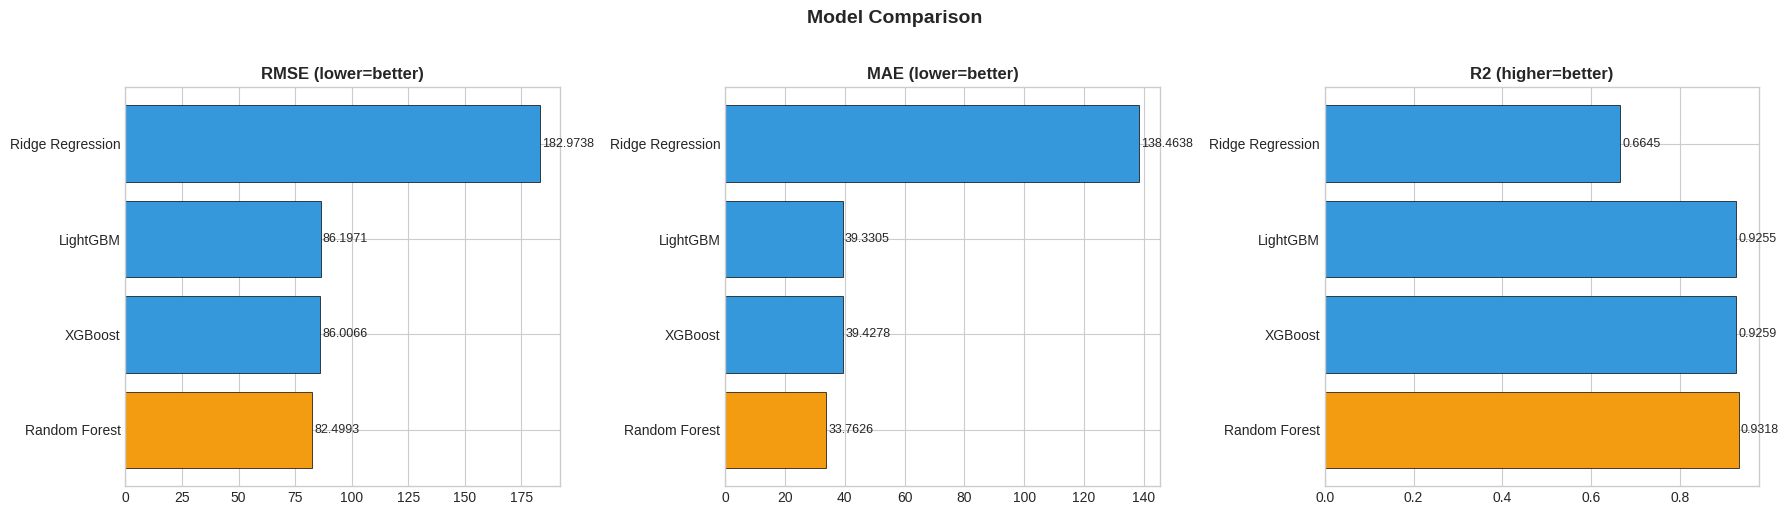

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#f39c12' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['rmse_mean', 'mae_mean', 'r2_mean'],
                              ['RMSE (lower=better)', 'MAE (lower=better)', 'R2 (higher=better)']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i, v in enumerate(vals):
        ax.text(v + 0.005 * max(vals), i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Residual Analysis

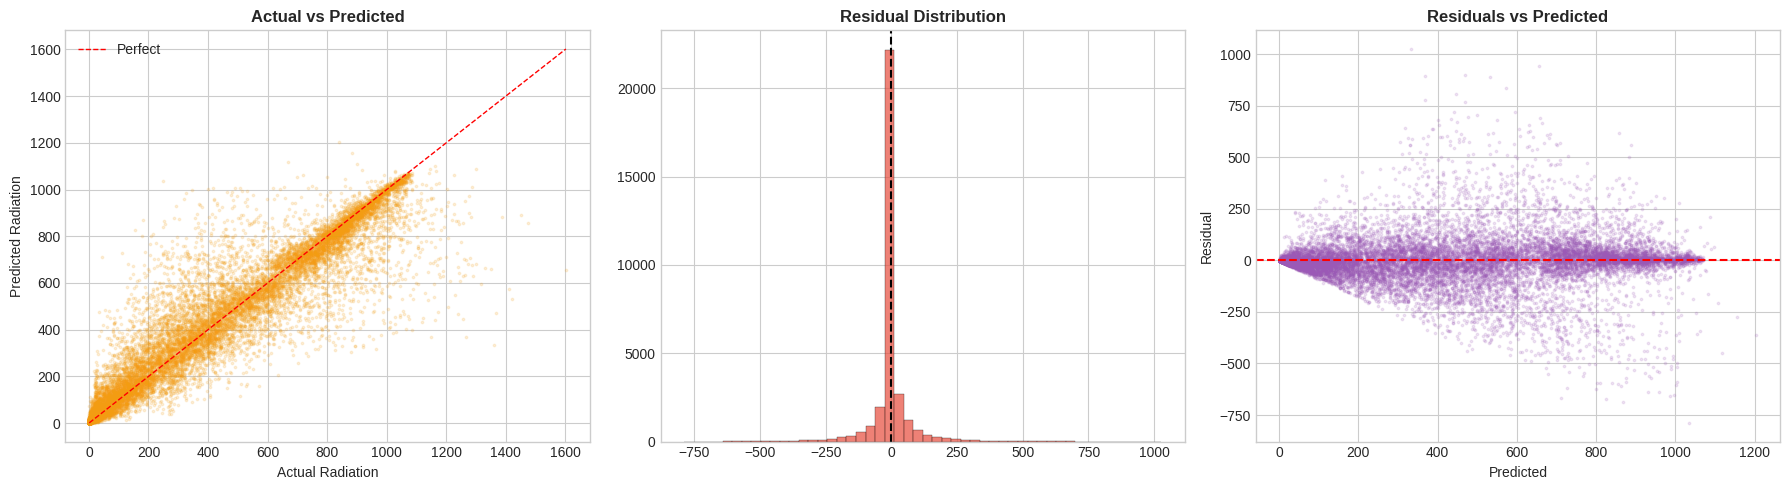

Residual mean: -0.52, std: 82.50
MAPE: 28.1%


In [14]:
best_preds = results[best_model_name]['oof_preds']
residuals = y - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y, best_preds, alpha=0.15, s=3, color='#f39c12')
lims = [min(y.min(), best_preds.min()), max(y.max(), best_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect')
axes[0].set_xlabel(f'Actual {target_col}'); axes[0].set_ylabel(f'Predicted {target_col}')
axes[0].set_title('Actual vs Predicted', fontsize=12, fontweight='bold'); axes[0].legend()

axes[1].hist(residuals, bins=50, color='#e74c3c', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')

axes[2].scatter(best_preds, residuals, alpha=0.15, s=3, color='#9b59b6')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel(f'Predicted'); axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"Residual mean: {residuals.mean():.2f}, std: {residuals.std():.2f}")
non_zero_mask = np.abs(y) > 1e-6
if non_zero_mask.sum() > 0:
    mape = np.mean(np.abs(residuals[non_zero_mask]) / np.abs(y[non_zero_mask])) * 100
    print(f"MAPE: {mape:.1f}%")


## 8. Feature Importance & Policy Insights

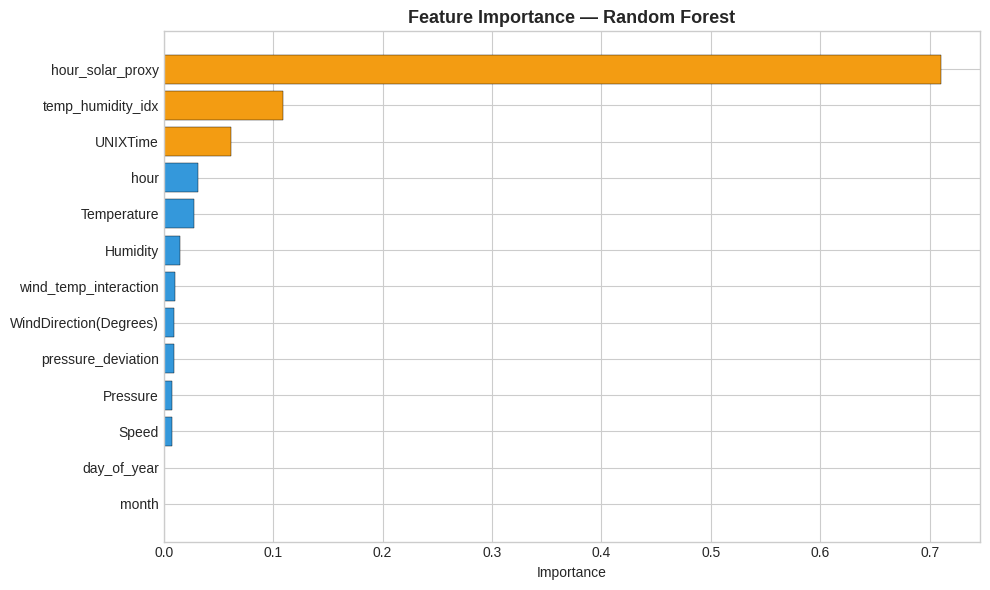

TOP 5 PREDICTIVE FEATURES
  hour_solar_proxy                0.7105
  temp_humidity_idx               0.1090
  UNIXTime                        0.0617
  hour                            0.0318
  Temperature                     0.0281


In [15]:
tree_models = {k: v for k, v in models.items() if k != 'Ridge Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['r2_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#f39c12' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:30s}  {row['Importance']:.4f}")


## 9. Deployment Readiness & Production Considerations

In [16]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  RMSE:                 {best_res['rmse_mean']:.4f}")
print(f"  MAE:                  {best_res['mae_mean']:.4f}")
print(f"  R-squared:            {best_res['r2_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold")
print("=" * 60)
checks = {
    'R2 > 0.60': best_res['r2_mean'] > 0.60,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Residual analysis done': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Random Forest
  RMSE:                 82.4993
  MAE:                  33.7626
  R-squared:            0.9318
  Training time:        31.7s
  Feature count:        13
  Dataset rows:         32,686
  CV strategy:          3-fold

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] R2 > 0.60
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Residual analysis done
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [17]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: BOM weather stations, AEMO solar generation SCADA
   Ingestion: BOM API -> Azure IoT Hub -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (5-min weather, satellite cloud imagery)
   Schedule: Real-time (5-min intervals aligned with NEM dispatch)

2. MODEL SERVING
   Framework: MLflow / ONNX for low-latency
   Endpoint: Real-time (<1s for 5-min ahead, batch for day-ahead)
   Ensemble: ML + NWP (numerical weather prediction) from BOM ACCESS model
   Horizons: 5-min (dispatch), 1-hour (trading), day-ahead (scheduling)

3. INTEGRATION POINTS
   AEMO: Feed into Australian Solar Energy Forecasting System (ASEFS)
   Market: 5-minute spot price forecasting for solar generators
   Network: Voltage management, curtailment prediction for DNSPs
   Retail: Customer solar export forecasting for billing/credits
   Investment: Yield estimation for solar farm project financing (CEFC)

4. GOVERNANCE
   Validation: Backtesting against AEMO actual generation data
   Uncertainty: Probabilistic forecasts (P10/P50/P90 confidence bands)
   Bias: Monitor for systematic over/under-prediction by season/region
   NEM compliance: Meets AEMO semi-scheduled generator forecasting rules

5. MONITORING & RETRAINING
   Drift: PSI on weather features daily
   Performance: RMSE vs AEMO benchmark forecasts weekly
   Retraining: Monthly with latest weather-generation pairs
   Seasonal: Separate models for summer/winter solar patterns
   Events: Bushfire smoke, volcanic aerosol, eclipse adjustment modes

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: BOM weather stations, AEMO solar generation SCADA
   Ingestion: BOM API -> Azure IoT Hub -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (5-min weather, satellite cloud imagery)
   Schedule: Real-time (5-min intervals aligned with NEM dispatch)

2. MODEL SERVING
   Framework: MLflow / ONNX for low-latency
   Endpoint: Real-time (<1s for 5-min ahead, batch for day-ahead)
   Ensemble: ML + NWP (numerical weather prediction) from BOM ACCESS model
   Horizons: 5-min (dispatch), 1-hour (trading), day-ahead (scheduling)

3. INTEGRATION POINTS
   AEMO: Feed into Australian Solar Energy Forecasting System (ASEFS)
   Market: 5-minute spot price forecasting for solar generators
   Network: Voltage management, curtailment prediction for DNSPs
   Retail: Customer solar export forecasting for billing/credits
   Investment: Yield estimation for solar farm project financing (CEFC)

4. GOVERNANCE
   Validation: Backtes